# PSF Moments Scatter Plots (v1)

**Author:** Aaron Roodman / Claude  
**Date Created:** 2026-03-18  
**Last Modified:** 2026-03-18  
**Status:** Draft  
**Keywords:** PSF, moments, ellipticity, FWHM, ConsDB  

## Description

Scatter plots of PSF moments vs sequence number for a given night, using the
`PSFMomentsTable` class to query per-CCD data from ConsDB.

Key functionality:
1. Fetch PSF moments (psf_sigma, psf_ixx, psf_iyy, psf_ixy) for 4 CCDs
2. Derive FWHM (arcsec) and ellipticity (e1, e2) per CCD
3. Scatter plots of all quantities vs seq_num

**Output:** Plots  
**Based on:** `common/psf_moments_consdb.py`

<a id='params'></a>
## 1. Parameters

In [1]:
# ============================================================
# Parameters — All configurable values collected here
# ============================================================

day_obs = 20260301               # Observation date
detectors = [94,95,96,97] # Corner raft CCDs
seq_min = 1
seq_max = 9999

<a id='setup'></a>
## 2. Setup & Imports

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from common.utils import setup_plotting
from common.psf_moments_consdb import PSFMomentsTable

setup_plotting()

# Constants
SIG2FWHM = 2 * np.sqrt(2 * np.log(2))
PIXEL_SCALE = 0.2  # arcsec / pixel

<a id='data'></a>
## 3. Fetch Data

In [3]:
psf = PSFMomentsTable(
    day_obs=day_obs,
    detectors=detectors,
    seq_min=seq_min,
    seq_max=seq_max,
)
table = psf.fetch()
print(f"{len(table)} visits retrieved for day_obs={day_obs}")
table[:5]

694 visits retrieved for day_obs=20260301


visit_id,day_obs,seq_num,psf_ixx_94,psf_ixx_95,psf_ixx_96,psf_ixx_97,psf_ixy_94,psf_ixy_95,psf_ixy_96,psf_ixy_97,psf_iyy_94,psf_iyy_95,psf_iyy_96,psf_iyy_97,psf_sigma_94,psf_sigma_95,psf_sigma_96,psf_sigma_97
int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
2026030100004,20260301,4,--,11.038547952824066,65.2004625610292,9.470381486133288,--,-10.20596011919936,0.9667872526967064,-0.36426878983283406,--,59.70006446862306,21.10435333455032,8.413130913379769,--,4.853354558063716,6.089503805936465,2.9864160486507343
2026030100005,20260301,5,29.9046342105821,14.945964855117444,39.60437035789453,40.66618597592379,3.760435976693696,5.794545877370124,6.008624945541268,4.475761339726879,14.006648242137446,21.379528737581836,13.484856435946309,14.411538792629893,4.485278571489396,4.112223140368802,4.723867107776475,4.877641070642638
2026030100006,20260301,6,34.897880355505336,24.924819845632125,37.35026062120334,28.659507866681885,9.595175447685405,15.814448602166577,5.763288234423748,14.534315833967957,33.32437735169733,26.14026950341223,37.11344455749946,34.49494243189177,5.720519625785794,4.4761686220822225,6.064890320912285,5.280265864504491
2026030100007,20260301,7,7.083480999593913,32.93743020853239,6.817012051448812,7.560007924827785,-0.5039462563331646,-2.555507067540261,-1.130409397006222,-1.0646088943120797,9.665304150117999,41.353385912984315,9.621146164303077,9.807286321220555,2.873836593144942,6.0677597448461835,2.8318420498022623,2.923110583706506
2026030100008,20260301,8,6.751193023948326,7.003692549915983,6.518548795271072,6.45037894159894,0.4955823755891177,0.5062729039984071,0.43933246672459,0.49720872710602265,5.4237011379165745,5.632144430814684,5.196214979590816,5.2475013048731025,2.4557738293060662,2.502029459228667,2.409012473234965,2.4076233841438888


<a id='derived'></a>
## 4. Derive FWHM and Ellipticity

In [4]:
for det in detectors:
    sigma = table[f"psf_sigma_{det}"]
    ixx = table[f"psf_ixx_{det}"]
    iyy = table[f"psf_iyy_{det}"]
    ixy = table[f"psf_ixy_{det}"]

    # FWHM in arcsec
    table[f"fwhm_{det}"] = sigma * SIG2FWHM * PIXEL_SCALE

    # Ellipticity components
    denom = ixx + iyy
    table[f"e1_{det}"] = (ixx - iyy) / denom
    table[f"e2_{det}"] = 2 * ixy / denom

print("Derived columns added.")

Derived columns added.


<a id='results'></a>
## 5. Scatter Plots vs Sequence Number

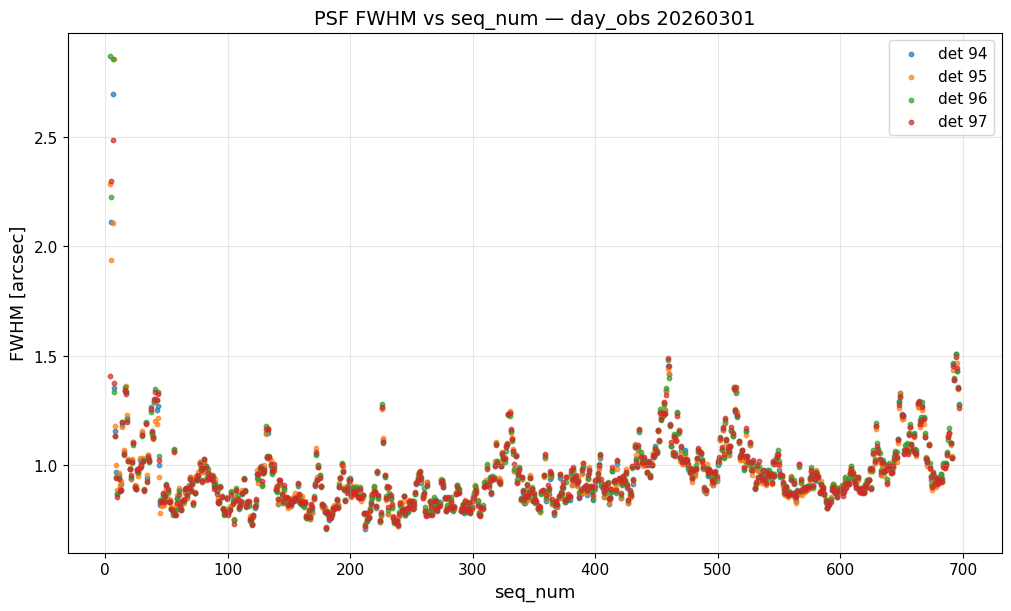

In [5]:
seq = table["seq_num"]

fig, ax = plt.subplots()
for det in detectors:
    ax.scatter(seq, table[f"fwhm_{det}"], s=10, label=f"det {det}", alpha=0.7)
ax.set_xlabel("seq_num")
ax.set_ylabel("FWHM [arcsec]")
ax.set_title(f"PSF FWHM vs seq_num — day_obs {day_obs}")
ax.legend()
plt.show()

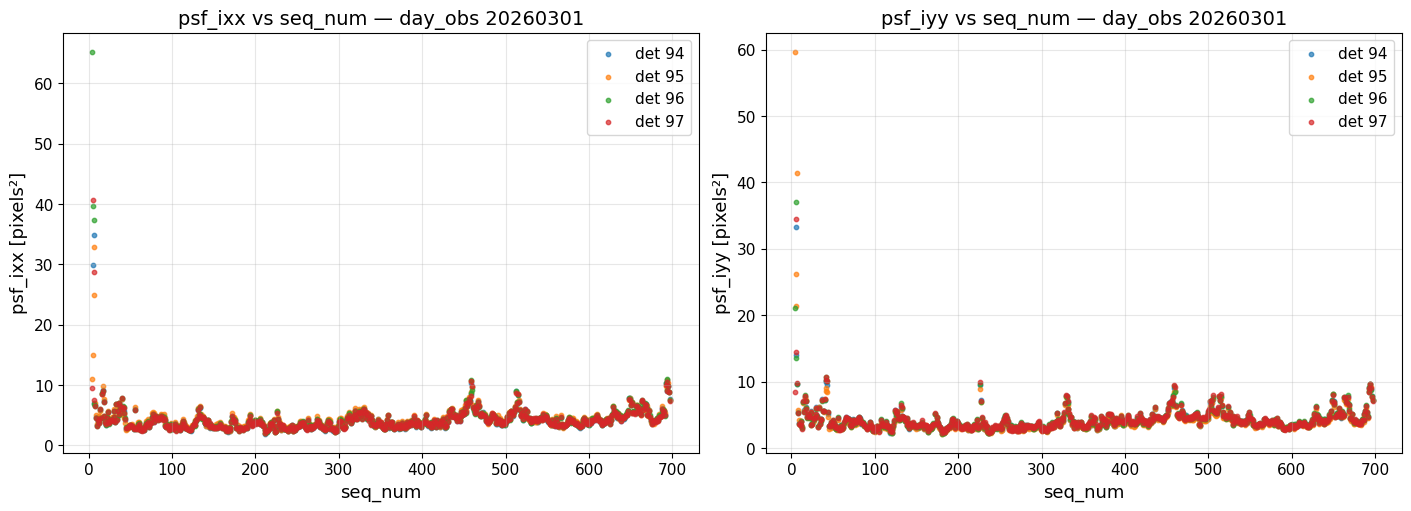

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for det in detectors:
    axes[0].scatter(seq, table[f"psf_ixx_{det}"], s=10, label=f"det {det}", alpha=0.7)
    axes[1].scatter(seq, table[f"psf_iyy_{det}"], s=10, label=f"det {det}", alpha=0.7)

axes[0].set_xlabel("seq_num")
axes[0].set_ylabel("psf_ixx [pixels²]")
axes[0].set_title(f"psf_ixx vs seq_num — day_obs {day_obs}")
axes[0].legend()

axes[1].set_xlabel("seq_num")
axes[1].set_ylabel("psf_iyy [pixels²]")
axes[1].set_title(f"psf_iyy vs seq_num — day_obs {day_obs}")
axes[1].legend()

plt.show()

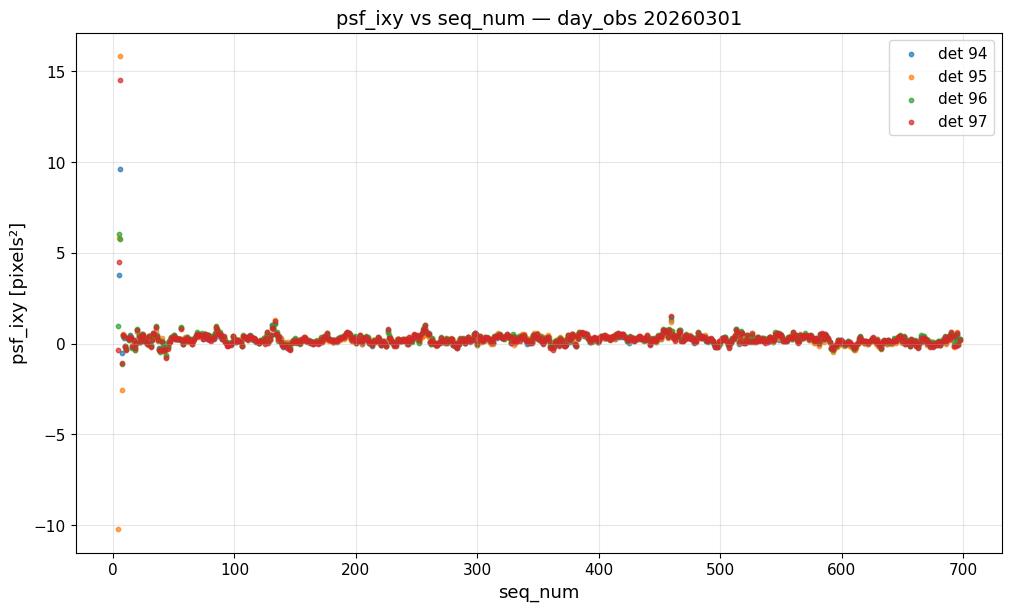

In [7]:
fig, ax = plt.subplots()
for det in detectors:
    ax.scatter(seq, table[f"psf_ixy_{det}"], s=10, label=f"det {det}", alpha=0.7)
ax.set_xlabel("seq_num")
ax.set_ylabel("psf_ixy [pixels²]")
ax.set_title(f"psf_ixy vs seq_num — day_obs {day_obs}")
ax.legend()
plt.show()

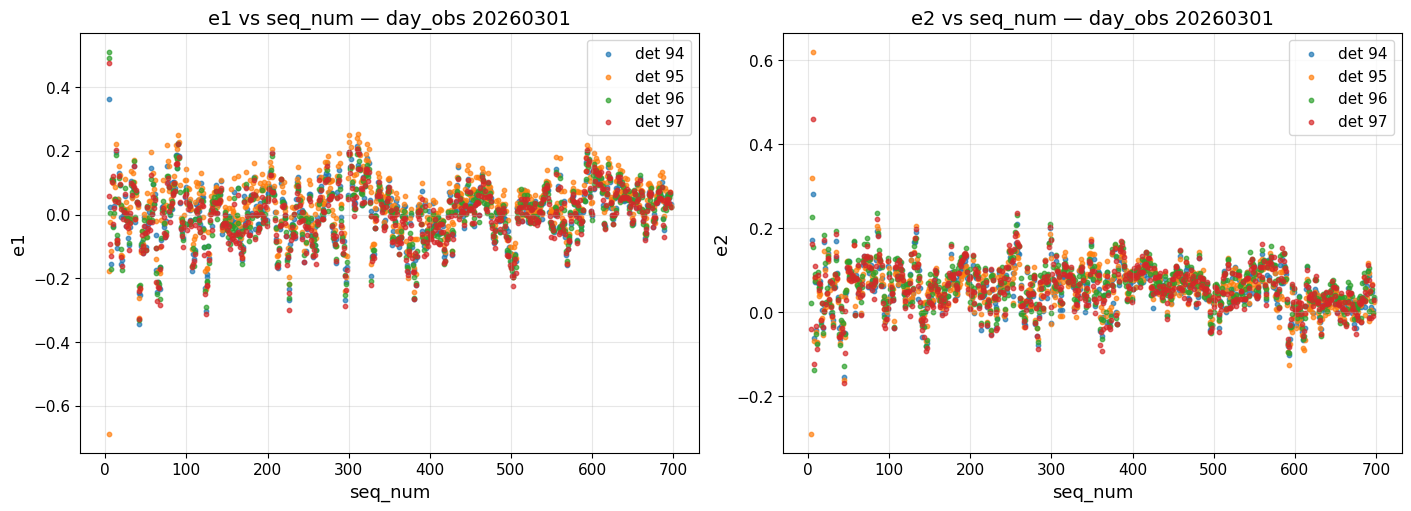

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for det in detectors:
    axes[0].scatter(seq, table[f"e1_{det}"], s=10, label=f"det {det}", alpha=0.7)
    axes[1].scatter(seq, table[f"e2_{det}"], s=10, label=f"det {det}", alpha=0.7)

axes[0].set_xlabel("seq_num")
axes[0].set_ylabel("e1")
axes[0].set_title(f"e1 vs seq_num — day_obs {day_obs}")
axes[0].legend()

axes[1].set_xlabel("seq_num")
axes[1].set_ylabel("e2")
axes[1].set_title(f"e2 vs seq_num — day_obs {day_obs}")
axes[1].legend()

plt.show()